In [31]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

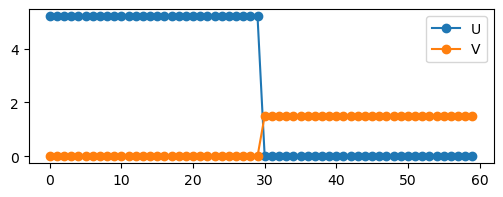

In [32]:
widthN = 30
widthF = 1
widthP = 30

X, Y = widthN+widthP, 61
lattice = Lattice(X, Y)
t = 1
T = 0.01

muN = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthN] = muN
mu[widthN:widthN + widthF] = muF
mu[widthN + widthF:widthN + widthF + widthP] = muP

hz0 = 0.9 * t
hz = np.zeros_like(mu)
hz[widthN:widthN + widthF] = hz0

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0
# U = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthN] = 0 
# V = None

V_prime = V0 * np.ones(lattice.X)
V_prime[:widthN] = 0
V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
# plt.plot(mu, '-o', label='mu')
# plt.plot(hz, '-o', label='hz')

plt.legend()

In [33]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.01, -0.01, 0.01j, -0.01j],
                hz=hz)#, F0_init=0.1)
                
                # Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                # Fdd_init=[0.01, -0.01, 0.01j, -0.01j])#, F0_init=0.1)


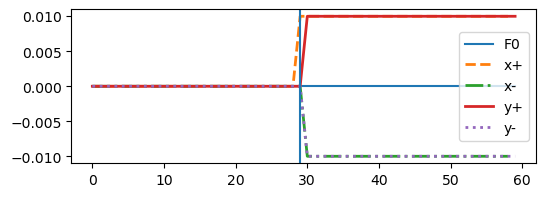

In [34]:
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [35]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=500, verbose=True, temperature=T)


F0:
Absolute error: 0.013127194250205105
Relative error: 13127194250.205107
Average old: 0j
Average: (-0.0007823201822232151+0j)
F_xplus:
Absolute error: 0.03540334482861987
Relative error: 5093745090.623133
Average old: (0.005084745762711865+0j)
Average: (0.008279896964941844+0j)
F_xmin:
Absolute error: 0.03646823569690912
Relative error: 6646923993.558561
Average old: (-0.004915254237288136+0j)
Average: (-0.008426235939595319+0j)
F_yplus:
Absolute error: 0.06337410480131331
Relative error: 9249660991.502699
Average old: 0.005000000000000001j
Average: (0.0005080180194916876+0.01108563342866547j)
F_ymin:
Absolute error: 0.06337410480131331
Relative error: 9249660991.502699
Average old: -0.005000000000000001j
Average: (0.0005080180194916876-0.01108563342866547j)
Fuu_xplus:
Absolute error: 1.7090469713095886e-17
Relative error: 1.7090469713095883e-05
Average old: 0j
Average: (5.006719946132939e-19+0j)
Fuu_xmin:
Absolute error: 1.5420578032370304e-17
Relative error: 1.5420578032370305e-05

In [36]:
F_yplus = H.Fuu_yplus + H.Fdd_yplus 
F_ymin = H.Fuu_ymin + H.Fdd_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.Fuu_xplus + H.Fdd_xplus
F_xmin[1:]  = H.Fuu_xmin + H.Fdd_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

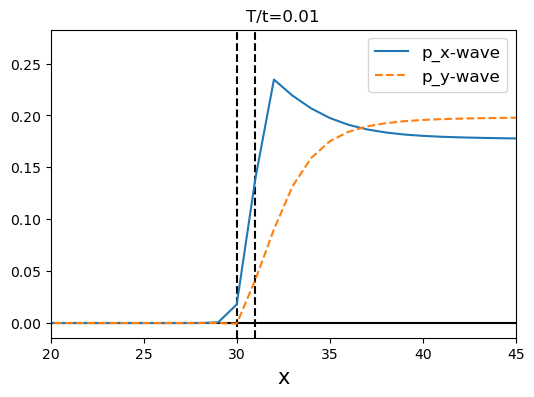

In [40]:
x = np.arange(1, widthN + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(6, 4))
axs.set_title(f"T/t={T}")
# axs.plot(x, np.real(F_swave), label="s-wave")
# axs.plot(x, np.real(F_dwave), label="d-wave")

axs.axhline(0, color = 'black')
axs.axvline(widthN, color='black', linestyle='--')
axs.axvline(widthN+widthF, color='black', linestyle='--')

axs.plot(x, np.real(F_px), label="p_x-wave")
axs.plot(x, np.imag(F_py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.set_xlim(20, 45)
# axs.set_ylim(0, None)
axs.legend(fontsize=12, loc="best")
plt.show()